# Basic

In [1]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()

In [3]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28 * 28)
(train_scaled, val_scaled, train_target, val_target) = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [4]:
keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

In [5]:
def model_fn(dropout_rate=None):
    model = keras.Sequential()
    model.add(keras.layers.Dense(100, activation='relu', input_shape=(784,)))
    if dropout_rate:
        model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [6]:
model_basic = model_fn(dropout_rate=0.3)

c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model_basic.compile(optimizer='adam', loss=keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

In [8]:
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss')

In [9]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model-basic.keras', save_best_only=True)

In [10]:
history = model_basic.fit(train_scaled, train_target, epochs=20, verbose=1,
                          validation_data=(val_scaled, val_target),
                          callbacks=[checkpoint, early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7895 - loss: 0.5958 - val_accuracy: 0.8474 - val_loss: 0.4276
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8424 - loss: 0.4397 - val_accuracy: 0.8577 - val_loss: 0.3875
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8534 - loss: 0.4022 - val_accuracy: 0.8643 - val_loss: 0.3660
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8620 - loss: 0.3796 - val_accuracy: 0.8672 - val_loss: 0.3625
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8687 - loss: 0.3626 - val_accuracy: 0.8758 - val_loss: 0.3426
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8694 - loss: 0.3536 - val_accuracy: 0.8772 - val_loss: 0.3357
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8733 - loss: 0.3421 - val_accuracy: 0.8718 - val_loss: 0.3475
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8768 - loss: 0.3357 - 

In [11]:

print("\n" + "="*30)
print(f"조기 종료된 에폭 (stopped_epoch): {early_stopping.stopped_epoch}")

# 검증 세트 평가
val_loss, val_accuracy = model_basic.evaluate(val_scaled, val_target, verbose=0)
print(f"최종 검증 정확도 (val_accuracy): {val_accuracy:.4f}")
print("="*30)


조기 종료된 에폭 (stopped_epoch): 14
최종 검증 정확도 (val_accuracy): 0.8806


# Applied

In [13]:
# 실험할 드롭아웃 비율 리스트
dropout_rates = [0.0, 0.2, 0.3, 0.5]


--- Dropout Rate: 0.0 실험 시작 ---


c:\Users\RookieFit\p1-data\c3-deep-learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Rate 0.0 -> Train Acc: 0.9371 / Val Acc: 0.8838

--- Dropout Rate: 0.2 실험 시작 ---
Rate 0.2 -> Train Acc: 0.9070 / Val Acc: 0.8878

--- Dropout Rate: 0.3 실험 시작 ---
Rate 0.3 -> Train Acc: 0.8961 / Val Acc: 0.8857

--- Dropout Rate: 0.5 실험 시작 ---
Rate 0.5 -> Train Acc: 0.8688 / Val Acc: 0.8748


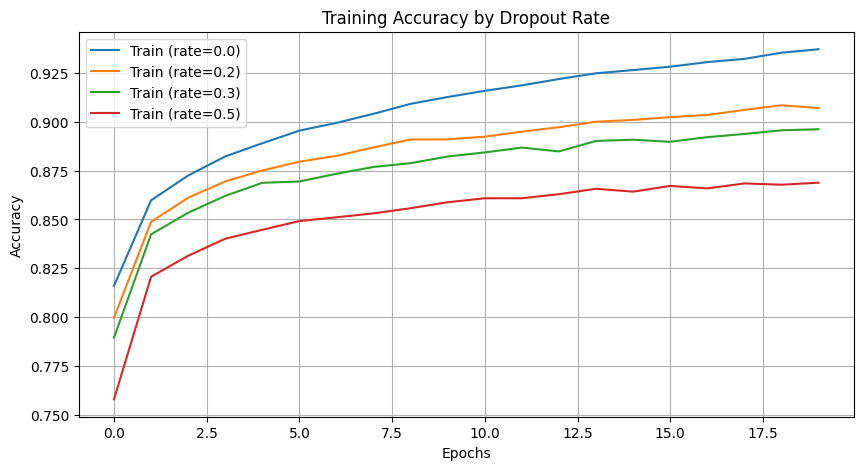

In [14]:
# 실험할 드롭아웃 비율 리스트
dropout_rates = [0.0, 0.2, 0.3, 0.5]

# 결과를 저장할 딕셔너리
results = {}

for rate in dropout_rates:
    print(f"\n--- Dropout Rate: {rate} 실험 시작 ---")
    
    # [요구사항] 매 실험마다 seed 재설정하여 실험 간의 공정성 확보
    keras.utils.set_random_seed(42)
    tf.random.set_seed(42)
    
    # 모델 생성 및 컴파일
    model_appli = model_fn(rate)
    model_appli.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # [요구사항] EarlyStopping 없이 epochs=20 고정 학습
    history_exp = model_appli.fit(
        train_scaled, train_target,
        epochs=20,
        validation_data=(val_scaled, val_target),
        verbose=0 # 콘솔이 너무 복잡해지지 않도록 학습 로그 숨김
    )
    
    # 20번째 에폭(최종 에폭)의 train_accuracy와 val_accuracy 추출
    final_train_acc = history_exp.history['accuracy'][-1]
    final_val_acc = history_exp.history['val_accuracy'][-1]
    
    # 결과 저장
    results[rate] = {
        'train_acc': final_train_acc,
        'val_acc': final_val_acc,
        'history': history_exp.history
    }
    
    print(f"Rate {rate} -> Train Acc: {final_train_acc:.4f} / Val Acc: {final_val_acc:.4f}")

# --- 관찰 포인트 시각화 ---
plt.figure(figsize=(10, 5))
for rate in dropout_rates:
    plt.plot(results[rate]['history']['accuracy'], label=f'Train (rate={rate})')
plt.title('Training Accuracy by Dropout Rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()